<a href="https://colab.research.google.com/github/Tecnologico-de-Monterrey-MNA/nlp-2023-Equipo-4/blob/main/Equipo4_semana06y07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**
## **Curso TI4039.10 Estrategia de implementación de servicios tecnológicos (Gpo 10) : Procesamiento de Lenguaje Natural (NLP)**
### **Tecnológico de Monterrey**
### **Prof Luis Eduardo Falcón Morales**

## **Actividad en Equipos - Semanas 6 y 7: Modelado de Temas : LSI / LDA**

### EQUIPO 4 

### Denisse Maria Ramirez Colmenero - A01561497

### Daniela Estévez Rodríguez - A01793723 

### Ernesto Nicanor Santillán Guerrero - A01793675

### José Ovalle Alvarado - A01150742

### Genaro Ramos Higuera - A00351269



#### En la actividad de esta semana trabajarás en equipos en el tema de modelado de temas (topic modeling).


#### 1.

Descarga el archivo noticiasTopicModeling.txt que se encuentra en Canvas. Este archivo consiste en 5658 noticias de varios periódicos de España. El archivo de texto es una lista en el siguiente formato:

[{“titular”:”Encabezado“, “texto”:”Cuerpo”}, ... , {“titular”:”Encabezado”,”texto”:”Cuerpo”}]

#### Donde “titular” es el encabezado de la noticia y “texto” es el cuerpo del texto de dicha noticia. En particular en esta actividad trabajarás solamente con los cuerpos de las noticias, sin incluir los encabezados. Carga dicho archivo y genera un DataFrame de Pandas llamado “df” y que contiene una única columna llamada “noticia” con 5658 renglones formados por los cuerpos de las noticias

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd  
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string
import ast

from pprint import pprint as pprint

In [ ]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/danielaestevezrodriguez/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/danielaestevezrodriguez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Cargamos la lista de stopwords en español que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(len(stopwords.words('spanish')))
print(stopwords.words('spanish'))

313
['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 'estamos', 'estáis', 'están'

Cargamos los datos del archivo <noticiasTopicModeling.txt>

In [ ]:
with open('noticiasTopicModeling.txt', 'r') as fp:
    data  = fp.read()
    details = ast.literal_eval(data)

In [ ]:
#TOMAMOS AHORA SOLO LOS TEXTOS DE LAS NOTICIAS Y LOS JUNTAMOS EN UNA LISTA
noticias=[]
for i in range(len(details)):
  dicc=details[i]#sacamos cada diccionario
  noticias.append(dicc['texto']) #extraemos el texto de la noticia

In [ ]:
len (noticias)#veamos que quedaron 5658 textos de noticias 
              #y dejamos fuera los encabezados

5658

In [ ]:
noticias[0]#VEAMOS LA PRIMERA NOTICIA

'"España ha dejado de ser católica", decía Manuel Azaña al comienzo de la Segunda República, cuando aquel Congreso de los Diputados aprobó las leyes laicistas. Era una metáfora, dejó de ser católica sobre el papel de la ley, pero no en las creencias de buena parte de su pueblo.                  Contra la migración y la integración europea: el programa de Vox para Europa Saber más           España, este domingo 10 de noviembre, ha dejado de ser una excepción en Europa por la potencia de la extrema derecha en su Parlamento. Pero también es una metáfora, pues precisamente lo excepcional era tener una dictadura a mediados de los setenta y que el dictador aún estuviera en un mausoleo después de 40 años muerto: no existía tal cosa ni en Portugal, Grecia, Italia y Alemania, países de  dictaduras fascistas.                   Pero en España, como sí pasó en Portugal, Italia y Alemania, no se derrotó al fascismo, el franquismo murió en la cama y con el harakiri de las Cortes franquistas; no hubo

In [ ]:
#CONVERTIMOS A DATAFRAME LAS NOTICIAS
df = pd.DataFrame(noticias, columns=['noticia'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   noticia  5658 non-null   object
dtypes: object(1)
memory usage: 44.3+ KB


In [ ]:
df.head()

,noticia
0,"""España ha dejado de ser católica"", decía Manu..."
1,El clima de crispación social en Ceuta ha lleg...
2,El Gobierno ha alegado la suspensión de plazos...
3,"Puedes mandar tu pregunta, sugerencia o queja ..."
4,Panamá debe entregar esta semana a la Corte In...


In [ ]:
X = df.noticia #ponemos el corpus en X

#### 2. Realiza un proceso de limpieza. Aplica el preprocesamiento que consideres adecuado para texto en español. Recuerda que el objetivo es identificar los tokens que describan mejor la distribución de cada tema

In [ ]:
def clean_tok(doc):
  # Realizamos los procedimientos de limpieza:
  # 1) Caracteres alfabéticos:** Solo consideramos caracteres alfabéticos. 
  #   Por lo que eliminamos signos de puntuación, caracteres especiales y números.
  # 2) Se consideran tokens de longitud mayor a 1.
  # 3) Simplificamos todo a minúsculas.
  # 4) Eliminamos las stopwords.
  # 5) Cada Noticia queda tokenizada por palabras, o cadena de caracteres alfabéticos.
  
  words = re.findall(r"\w*(?:[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]{2,})",doc)
  tokens=[]
  for x in words:
    if x.lower() not in stopwords.words('spanish'):
      tokens.append(x.lower())    

  return tokens

In [ ]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]   

Veamos los primeras noticias.

In [ ]:
for x in Xcleantok[0:2]: # Vemos aqui las primeras 2 noticias
  print(x)

['españa', 'dejado', 'ser', 'católica', 'decía', 'manuel', 'azaña', 'comienzo', 'segunda', 'república', 'aquel', 'congreso', 'diputados', 'aprobó', 'leyes', 'laicistas', 'metáfora', 'dejó', 'ser', 'católica', 'papel', 'ley', 'creencias', 'buena', 'parte', 'pueblo', 'migración', 'integración', 'europea', 'programa', 'vox', 'europa', 'saber', 'españa', 'domingo', 'noviembre', 'dejado', 'ser', 'excepción', 'europa', 'potencia', 'extrema', 'derecha', 'parlamento', 'metáfora', 'pues', 'precisamente', 'excepcional', 'tener', 'dictadura', 'mediados', 'setenta', 'dictador', 'aún', 'mausoleo', 'después', 'años', 'muerto', 'existía', 'tal', 'cosa', 'portugal', 'grecia', 'italia', 'alemania', 'países', 'dictaduras', 'fascistas', 'españa', 'pasó', 'portugal', 'italia', 'alemania', 'derrotó', 'fascismo', 'franquismo', 'murió', 'cama', 'harakiri', 'cortes', 'franquistas', 'ruptura', 'régimen', 'sino', 'reforma', 'nació', 'nuevo', 'país', 'sino', 'país', 'mutó', 'ley', 'ley', 'aun', 'así', 'españa', 

**Comentario**


Intentamos realizar un proceso de stemming utilizando Snowball Stemmer y otro de lematización utilizando spaCy por separado. Sin embargo, ninguno de estos enfoques logró mejorar la interpretación de los temas ni las métricas de coherencia.

In [ ]:
Xclean=Xcleantok #YA NO HACEMOS MAS PROCESOS ADICIONALES DE LIMPIEZA

In [ ]:
Xclean[0]         # Veamos la primera noticia.

['españa',
 'dejado',
 'ser',
 'católica',
 'decía',
 'manuel',
 'azaña',
 'comienzo',
 'segunda',
 'república',
 'aquel',
 'congreso',
 'diputados',
 'aprobó',
 'leyes',
 'laicistas',
 'metáfora',
 'dejó',
 'ser',
 'católica',
 'papel',
 'ley',
 'creencias',
 'buena',
 'parte',
 'pueblo',
 'migración',
 'integración',
 'europea',
 'programa',
 'vox',
 'europa',
 'saber',
 'españa',
 'domingo',
 'noviembre',
 'dejado',
 'ser',
 'excepción',
 'europa',
 'potencia',
 'extrema',
 'derecha',
 'parlamento',
 'metáfora',
 'pues',
 'precisamente',
 'excepcional',
 'tener',
 'dictadura',
 'mediados',
 'setenta',
 'dictador',
 'aún',
 'mausoleo',
 'después',
 'años',
 'muerto',
 'existía',
 'tal',
 'cosa',
 'portugal',
 'grecia',
 'italia',
 'alemania',
 'países',
 'dictaduras',
 'fascistas',
 'españa',
 'pasó',
 'portugal',
 'italia',
 'alemania',
 'derrotó',
 'fascismo',
 'franquismo',
 'murió',
 'cama',
 'harakiri',
 'cortes',
 'franquistas',
 'ruptura',
 'régimen',
 'sino',
 'reforma',
 'na

Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
midiccionario = Counter()    

for k in range(len(Xclean)):
  midiccionario.update(Xclean[k])


print('Longitud del diccionario:', len(midiccionario))  
print('\n(word,frequency):') 
print(midiccionario.most_common(20)) 

Longitud del diccionario: 100373

(word,frequency):
[('si', 10706), ('gobierno', 10326), ('años', 7546), ('dos', 7399), ('personas', 7068), ('coronavirus', 6787), ('ser', 6650), ('madrid', 6170), ('según', 6051), ('españa', 6016), ('parte', 5957), ('etiquetas', 5709), ('caso', 5650), ('ahora', 5449), ('solo', 5193), ('pp', 5108), ('cada', 5009), ('así', 4922), ('sido', 4785), ('días', 4635)]


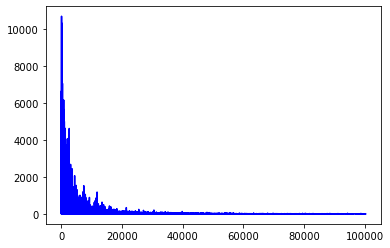

In [ ]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

Descartemos palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

In [ ]:
# DECIDIMOS BUSCAR UNA FRECUENCIA MINIMA PARA TENER APROX DE 10,000 TOKENS EN EL
#NUEVO VOCABULARIO, DESPUES DE VARIAS PRUEBAS VEMOS QUE LA FRECUENCIA MINIMA ES 
min_freq = 32

midicc ={}        # Construyamos un diccionario de la forma: {key:value} --> {tupla:freq_class} --> {(word,class):freq_class}
for x in midiccionario.keys():
  if midiccionario[x] >= min_freq:
     midicc[x]=midiccionario[x]


print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:20])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 10029
[('españa', 6016), ('dejado', 747), ('ser', 6650), ('católica', 93), ('decía', 421), ('manuel', 889), ('comienzo', 226), ('segunda', 1405), ('república', 359), ('aquel', 703), ('congreso', 1576), ('diputados', 694), ('aprobó', 306), ('leyes', 289), ('metáfora', 38), ('dejó', 456), ('papel', 825), ('ley', 2261), ('creencias', 43), ('buena', 818)]


Filtramos el vocabulario propuesto:

In [ ]:
new_X = []
for ss in Xclean:
  new_X.append([w for w in ss if w in midicc])


In [ ]:
# Podemos ver algunos de las noticias, antes y después 
# de incluir la condición de la frecuencia mínima de ocurrencia de un token:

for k in range(3):
  print('Antes:', Xclean[k])
  print('Después:', new_X[k])

Antes: ['españa', 'dejado', 'ser', 'católica', 'decía', 'manuel', 'azaña', 'comienzo', 'segunda', 'república', 'aquel', 'congreso', 'diputados', 'aprobó', 'leyes', 'laicistas', 'metáfora', 'dejó', 'ser', 'católica', 'papel', 'ley', 'creencias', 'buena', 'parte', 'pueblo', 'migración', 'integración', 'europea', 'programa', 'vox', 'europa', 'saber', 'españa', 'domingo', 'noviembre', 'dejado', 'ser', 'excepción', 'europa', 'potencia', 'extrema', 'derecha', 'parlamento', 'metáfora', 'pues', 'precisamente', 'excepcional', 'tener', 'dictadura', 'mediados', 'setenta', 'dictador', 'aún', 'mausoleo', 'después', 'años', 'muerto', 'existía', 'tal', 'cosa', 'portugal', 'grecia', 'italia', 'alemania', 'países', 'dictaduras', 'fascistas', 'españa', 'pasó', 'portugal', 'italia', 'alemania', 'derrotó', 'fascismo', 'franquismo', 'murió', 'cama', 'harakiri', 'cortes', 'franquistas', 'ruptura', 'régimen', 'sino', 'reforma', 'nació', 'nuevo', 'país', 'sino', 'país', 'mutó', 'ley', 'ley', 'aun', 'así', 'es

In [ ]:
new_X_docs = []
for k in range(len(new_X)):
  new_X_docs.append(' '.join(new_X[k]))

# Vemos ahora las primeras 3 noticias están cada uno como un solo string:
for k in range(3):
  print(new_X_docs[k])

españa dejado ser católica decía manuel comienzo segunda república aquel congreso diputados aprobó leyes metáfora dejó ser católica papel ley creencias buena parte pueblo migración integración europea programa vox europa saber españa domingo noviembre dejado ser excepción europa potencia extrema derecha parlamento metáfora pues precisamente excepcional tener dictadura mediados setenta dictador aún después años muerto existía tal cosa portugal grecia italia alemania países fascistas españa pasó portugal italia alemania fascismo franquismo murió cama cortes franquistas ruptura régimen sino reforma nació nuevo país sino país ley ley aun así españa parecía si años franquismo sido bastantes llegado irrupción tras ser actores fundamentales gobiernos autonómicos locales pp ciudadanos españa dejado ser excepción aunque alianza popular manuel fraga franquismo fuerza nueva blas franquista aunque franquismo pp largo tiempos aunque vox propio pp aunque así cierto nunca ahora españa democrática exi

In [ ]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

### 3. ¿Por qué en este caso no requerimos hacer una partición en entrenamiento, validación y prueba?

En este caso, no es necesario realizar una partición en conjuntos de entrenamiento, validación y prueba debido a que el objetivo principal es identificar los tokens que describan mejor la distribución de cada tema. En este contexto, estamos abordando un problema de aprendizaje no supervisado, donde el enfoque se centra en agrupar un conjunto de textos (corpus) en grupos afines sin la necesidad de contar con etiquetas o clasificaciones predefinidas.

La evaluación de los resultados en este tipo de aprendizaje no supervisado dependerá en gran medida del usuario final. La finalidad es explorar y descubrir patrones, similitudes y características significativas en los textos sin la necesidad de tener una referencia externa para la evaluación.

Por lo tanto, en lugar de realizar una partición en conjuntos de entrenamiento, validación y prueba, el enfoque se centrará en técnicas de procesamiento de lenguaje natural, para identificar y analizar los tokens que mejor describan la distribución de cada tema.

En resumen, en este caso particular, no se requiere una partición en conjuntos de datos específicos, ya que el objetivo es explorar y descubrir características de los textos en un enfoque de aprendizaje no supervisado, donde la evaluación y la interpretación de los resultados dependerán del análisis y la interpretación del usuario final.

# Parte 1: Indexación semántica latente (LSI):

### 4. Encontrar la matriz Tf-idf de la columna de noticias. Despliega los primeros 5 renglones con algunas de sus columnas con sus nombres, donde las columnas son los tokens. ¿Cuál es el significado de cada renglón? ¿Y el significado de cada columna?

In [ ]:
##############################################################################

from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab, norm=None)
new_X_tfidf = tfidfvectorizer.fit_transform(new_X_docs)

### Primeros comentarios de train_x_tfidf
tfidf_tokens_X = tfidfvectorizer.get_feature_names_out()
df_tfidfvect_X = pd.DataFrame(data = new_X_tfidf.toarray(),  columns = tfidf_tokens_X)  



In [ ]:
df_tfidfvect_X.head()

,españa,dejado,ser,católica,decía,manuel,comienzo,segunda,república,aquel,...,digestivo,lagunas,obieta,diplocat,pontón,exoneraciones,pence,avalmadrid,recicladores,heeney
0,13.661420,9.529243,8.223426,11.060257,3.835868,6.611896,4.327796,2.83528,4.308284,3.473486,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.951631,0.000000,1.644685,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.951631,0.000000,1.644685,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,4.934056,0.000000,0.000000,3.305948,0.000000,0.00000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,1.644685,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Respuesta pregunta 4: 

Cada valor numérico en la tabla nos habla de la importancia de cada palabra o término dentro de cada documento. De esta manera, las columnas representan las palabras o tokens, y los renglones representan los documentos. Cada valor en la tabla indica la relevancia o importancia de esa palabra en un documento específico.

En otras palabras, la matriz Tf-idf nos permite medir la importancia relativa de las palabras en un documento en comparación con el corpus completo. Los valores más altos indican que una palabra es más relevante en ese documento en particular, mientras que los valores más bajos indican una menor relevancia.

Es importante destacar que la matriz Tf-idf es una representación numérica de los textos que permite capturar la importancia de las palabras dentro de cada documento y facilita el procesamiento de texto en tareas de análisis y modelado de datos.

En resumen, cada renglón de la tabla representa un documento y cada columna representa una palabra o token, mientras que los valores numéricos indican la importancia de cada palabra en cada documento.

### 5. Aplica el método de descomposición de valores singulares truncado a la matriz Tf-idf anterior con 10 componentes y obtener el gráfico de la importancia relativa de estas.

In [ ]:
from sklearn.decomposition import TruncatedSVD
import seaborn as sns

In [ ]:
# Se define el objeto que aplicará SVD truncada con r valores singulares:

r = 10    # Máxima cantidad de valores singulares a considerar --> tópicos a generar:

lsi_obj = TruncatedSVD(n_components = r, 
                       n_iter=100,  # número de iteraciones ... recordemos que es un método iterativo.
                       random_state=42) 

tfidf_lsi = lsi_obj.fit_transform(new_X_tfidf)    # ndarray: se ajusta y aplica la SVD truncada.


Sigma = lsi_obj.singular_values_     # ndarray_(r,)



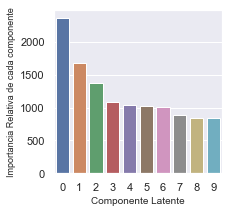

In [ ]:
sns.set(rc={'figure.figsize':(3,3)}) 
chart = sns.barplot(x=list(range(len(Sigma))), y = Sigma )
chart.set_xlabel('Componente Latente', fontdict={'size': 10})
chart.set_ylabel('Importancia Relativa de cada componente', fontdict={'size': 9})
plt.show()

### 6. Obtener la matriz tokens-temas (term-topic) a partir de la matriz 𝑉􏰀 de la descomposición SVD. Despliega sus primeros 5 renglones donde se incluya el nombre de las columnas.


In [ ]:
V_T = lsi_obj.components_.T         # ndarray_(n_terms X r)  
                                    # Las r columnas son los r temas/topics generados
                                    # Se ordenan los n_terms/words de mayor a menor para 
                                    # obtener las keywords principales de cada tópico.

In [ ]:
# La matriz V-transpuesta es la que genera la relación Terms(word)-Topics,
# los renglones son los términos/words y las columnas los tópicos/temas:

lsi_term_topic = V_T 

print(lsi_term_topic.shape)

(10029, 10)


In [ ]:
# rescatemos los nombres de los términos/tokens:

term_names = list(tfidfvectorizer.get_feature_names_out())

print(term_names[0:100]) #visualizamos los primeros 100

['españa', 'dejado', 'ser', 'católica', 'decía', 'manuel', 'comienzo', 'segunda', 'república', 'aquel', 'congreso', 'diputados', 'aprobó', 'leyes', 'metáfora', 'dejó', 'papel', 'ley', 'creencias', 'buena', 'parte', 'pueblo', 'migración', 'integración', 'europea', 'programa', 'vox', 'europa', 'saber', 'domingo', 'noviembre', 'excepción', 'potencia', 'extrema', 'derecha', 'parlamento', 'pues', 'precisamente', 'excepcional', 'tener', 'dictadura', 'mediados', 'setenta', 'dictador', 'aún', 'después', 'años', 'muerto', 'existía', 'tal', 'cosa', 'portugal', 'grecia', 'italia', 'alemania', 'países', 'fascistas', 'pasó', 'fascismo', 'franquismo', 'murió', 'cama', 'cortes', 'franquistas', 'ruptura', 'régimen', 'sino', 'reforma', 'nació', 'nuevo', 'país', 'aun', 'así', 'parecía', 'si', 'sido', 'bastantes', 'llegado', 'irrupción', 'tras', 'actores', 'fundamentales', 'gobiernos', 'autonómicos', 'locales', 'pp', 'ciudadanos', 'aunque', 'alianza', 'popular', 'fraga', 'fuerza', 'nueva', 'blas', 'franq

In [ ]:
# Y generamos un DataFrame con la matriz term-topic:

term_topic_matrix = pd.DataFrame(data=lsi_term_topic, 
                                 index = term_names,   
                                 columns = [f'Concepto_Latente_{r}' for r in range(0,V_T.shape[1])]
                                )

print(term_topic_matrix.shape)   #  words X topics

(10029, 10)


In [ ]:
term_topic_matrix.head()

,Concepto_Latente_0,Concepto_Latente_1,Concepto_Latente_2,Concepto_Latente_3,Concepto_Latente_4,Concepto_Latente_5,Concepto_Latente_6,Concepto_Latente_7,Concepto_Latente_8,Concepto_Latente_9
españa,0.091269,-0.007780,0.002916,-0.057384,0.022612,0.016898,-0.003585,-0.023262,-0.033358,0.005195
dejado,0.016500,-0.002379,-0.003761,-0.006674,0.000551,-0.001001,0.005361,0.001721,-0.008154,-0.009792
ser,0.085804,0.004644,0.010201,0.021592,-0.005647,-0.048575,-0.036225,-0.040602,-0.003440,-0.011853
católica,0.003041,-0.000268,-0.002723,-0.000043,0.000001,-0.003342,-0.005875,-0.002502,0.000699,0.000107
decía,0.013635,-0.000280,-0.012626,0.000926,0.002921,-0.005029,-0.005209,-0.013676,-0.001328,-0.012026


### 7. Con base a la cantidad de conceptos latentes que determinaste en el ejercicio 6 anterior, obtener cada uno de sus gráficos con sus 10 términos/tokens más importantes. ¿Cómo describirías cada uno de dichos conceptos latentes?

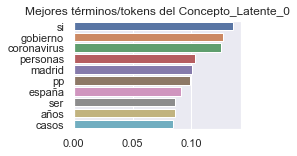

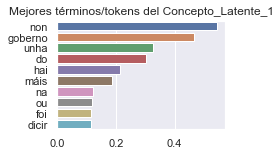

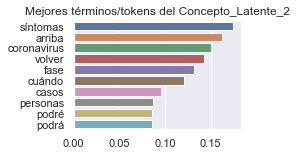

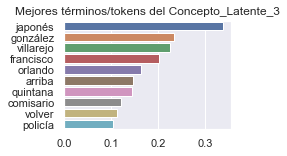

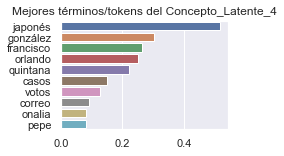

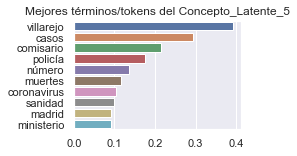

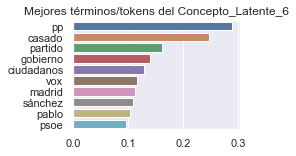

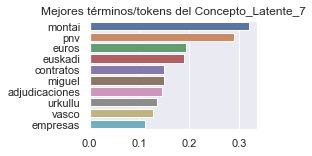

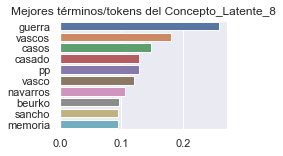

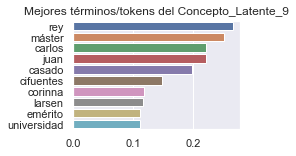

In [ ]:
for i in range(10): 
    concepto = f'Concepto_Latente_{i}'
    data = term_topic_matrix[concepto]
    data = data.sort_values(ascending=False) # Con la opción True, visualizarás los de menor peso.    
    top_w = 10      # Define la cantidad de las mejores "top_w" términos/words a visualizar.
    top_w_matrix = data[:top_w]    # Nos quedamos con los mejores top_w pesos, asociados a 
                               # los top_w terms (words).
    
    sns.set(rc={'figure.figsize':(3,2)}) 
    plt.title(f'Mejores términos/tokens del {concepto}')
    fig = sns.barplot(x= top_w_matrix.values, y=top_w_matrix.index)
    plt.show()

Concepto latente 0: habla sobre el topico de las enfermedades por Coronavirus en España.

Concepto latente 1: habla sobre gobierno y politicas.

Concepto latente 2: habla sobre el Coronavirus y sus sintomas.

Concepto latente 3: habla sobre el comisario de la Policia.

Concepto latente 4: habla sobre votaciones y politica.

Concepto latente 5: habla sobre las muertes resultantes del Coronavirus en Madrid. 

Concepto latente 6: habla sobre politica y gobierno en Madrid.

Concepto latente 7: habla sobre empresas vascas y contratos por adjudicaciones.

Concepto latente 8: habla sobre conflictos vascos.

Concepto latente 9: habla sobre el Rey Juan Carlos.

### 8. Para cada uno de los 10 conceptos latentes obtenidos con la descomposición SVD del ejercicio 5, obtener el gráfico de barras que muestre los 10 términos/tokens más importantes de cada uno de ellos

**ES LA MISMA QUE LA 7**

### 9. Con base a los resultados del ejercicio anterior, ¿cuántos tópicos o conceptos latentes identificas con claridad? ¿Cómo os describirías, es decir, de qué temáticas estarían hablando?

In [ ]:
# Lista de temas
temas=["0 : Coronavirus en España",
       "1 : Gobierno y política",
       "2 : Coronavirus y sus síntomas",
       "3 : Comisario de la Policia",
       "4 : Votaciones y política",
       "5 : Coronavirus en Madrid",
       "6 : Política en Madrid",
       "7 : Empresas Vascas y contratos por adjudicaciones",
       "8 : Conflictos Vascos",
       "9 : Rey Juan Carlos"]

In [ ]:
# Creamos un dataframe de las palabras más comunes en los 10 tópicos

aux={}

for c in term_topic_matrix.columns:
    temp=np.array(term_topic_matrix[c].sort_values(ascending=False)[0:10].index)
    aux[temas[int(c[-1])]]=temp
    
df=pd.DataFrame(aux)
df

,0 : Coronavirus en España,1 : Gobierno y política,2 : Coronavirus y sus síntomas,3 : Comisario de la Policia,4 : Votaciones y política,5 : Coronavirus en Madrid,6 : Política en Madrid,7 : Empresas Vascas y contratos por adjudicaciones,8 : Conflictos Vascos,9 : Rey Juan Carlos
0,si,non,síntomas,japonés,japonés,villarejo,pp,montai,guerra,rey
1,gobierno,goberno,arriba,gonzález,gonzález,casos,casado,pnv,vascos,máster
2,coronavirus,unha,coronavirus,villarejo,francisco,comisario,partido,euros,casos,carlos
3,personas,do,volver,francisco,orlando,policía,gobierno,euskadi,casado,juan
4,madrid,hai,fase,orlando,quintana,número,ciudadanos,contratos,pp,casado
5,pp,máis,cuándo,arriba,casos,muertes,vox,miguel,vasco,cifuentes
6,españa,na,casos,quintana,votos,coronavirus,madrid,adjudicaciones,navarros,corinna
7,ser,ou,personas,comisario,correo,sanidad,sánchez,urkullu,beurko,larsen
8,años,foi,podré,volver,onalia,madrid,pablo,vasco,sancho,emérito
9,casos,dicir,podrá,policía,pepe,ministerio,psoe,empresas,memoria,universidad


In [ ]:
# Lista
claridad=np.array(["Tema Claro",
          "Tema Algo Claro",
          "Tema Claro",
          "Tema Algo Claro",
          "Tema Algo Claro",
          "Tema Claro",
          "Tema Claro",
          "Tema Claro",
          "Tema Algo Claro",
          "Tema Claro"])

aux2={}
for i in range(10):
    aux2[temas[i]]=claridad[i]

aux2

{'0 : Coronavirus en España': 'Tema Claro',
 '1 : Gobierno y política': 'Tema Algo Claro',
 '2 : Coronavirus y sus síntomas': 'Tema Claro',
 '3 : Comisario de la Policia': 'Tema Algo Claro',
 '4 : Votaciones y política': 'Tema Algo Claro',
 '5 : Coronavirus en Madrid': 'Tema Claro',
 '6 : Política en Madrid': 'Tema Claro',
 '7 : Empresas Vascas y contratos por adjudicaciones': 'Tema Claro',
 '8 : Conflictos Vascos': 'Tema Algo Claro',
 '9 : Rey Juan Carlos': 'Tema Claro'}

Algunos de los topicos fueron más sencillos de identificar, como los topicos de los conceptos latentes 0,2,5,6 y 7. Sin embargo, pudimos identificar el tema de todos los conceptos latentes que analizamos.

### 10. La librería de código abierto Gensim, incluye la implementación de la técnica LSI. Ver documentación: https://radimrehurek.com/gensim/models/lsimodel.html

In [ ]:
import gensim
import gensim.corpora as corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel


#### Investiga la documentación de este modelo LSI en Gensim y aplica dicha técnica a tu conjunto de datos. En particular, obtener los modelos de 2 a 10 temas/tópicos y para cada uno de ellos obtener su valor (score) de coherencia. Con base a dichos valores, ¿qué cantidad de tópicos sería el adecuado? ¿Coincide con lo que obtuviste previamente, usando la técnica SVD de manera directa?

In [ ]:
mi_dicc = corpora.Dictionary(new_X)     # generamos el diccionario

bow = [mi_dicc.doc2bow(doc) for doc in new_X]   # y luego la BOW

In [ ]:
for i in range(2,11):
    
    lsi = LsiModel(bow, 
                   num_topics=i, 
                   id2word=mi_dicc,
                   chunksize=128,
                   power_iters=4,
                   random_seed=7)     
    
    cm = CoherenceModel(model=lsi, 
                        texts=new_X, 
                        dictionary=mi_dicc, 
                        window_size=3,
                        coherence='c_v',
                        topn=3
                       )
    
    cs = cm.get_coherence()
    
    print('Métrica de Coherencia con {} clusters: {}'.format(i, cs))

Métrica de Coherencia con 2 clusters: 0.5792237901724548
Métrica de Coherencia con 3 clusters: 0.537943859498731
Métrica de Coherencia con 4 clusters: 0.5822252742191731
Métrica de Coherencia con 5 clusters: 0.6520927281892643
Métrica de Coherencia con 6 clusters: 0.7320697549989
Métrica de Coherencia con 7 clusters: 0.6224222977400095
Métrica de Coherencia con 8 clusters: 0.6620589712928504
Métrica de Coherencia con 9 clusters: 0.6423274845197187
Métrica de Coherencia con 10 clusters: 0.550428223175911


Basándonos en los resultados anteriores y al probar diferentes tamaños de chunk, llegamos a la conclusión de que la cantidad de tópicos más adecuada es de 6.

En relación al ejercicio anterior utilizando SVD, observamos que también obtenemos 6 tópicos diferentes y 4 tópicos que son muy similares a los 6 identificados previamente.

## Parte 2: Asignación de Dirichlet Latente (LDA):


In [ ]:
#!pip install gensim

### 11. Utiliza la librería Gensim para implementar ahora la técnica de LDA. Revisa la documentación correspondiente y aplica de preferencia el modelo paralelizable: https://radimrehurek.com/gensim/models/ldamodel.html https://radimrehurek.com/gensim/models/ldamulticore.html

In [ ]:
dictionary = corpora.Dictionary(new_X)
print(f"Total de palabras antes de filtrado: {len(dictionary) }")

Total de palabras antes de filtrado: 10029


In [ ]:
# Filter infrequent or too frequent words.
dictionary.filter_extremes(no_below=10)
print(f"Total de palabras despues de filtrado: {len(dictionary) }")
corpus = [dictionary.doc2bow(tok) for tok in new_X]

Total de palabras despues de filtrado: 9945


In [ ]:
temp = dictionary[0] # This is only to "load" the dictionary.
id2word = dictionary.id2token

In [ ]:
type(id2word)

dict

In [ ]:
from gensim.models import LdaMulticore

In [ ]:
model = LdaMulticore(corpus=corpus, id2word=id2word,passes=8, num_topics=4,workers=10)
top_topics = list(model.top_topics(corpus))
pprint(top_topics)

[([(0.003941611, 'mujeres'),
   (0.003309837, 'personas'),
   (0.0031486414, 'solo'),
   (0.0029027315, 'así'),
   (0.0028771863, 'vida'),
   (0.0028597529, 'hace'),
   (0.0028084228, 'puede'),
   (0.0026669821, 'ahora'),
   (0.0025149994, 'vez'),
   (0.0024702973, 'después'),
   (0.0024264776, 'sido'),
   (0.0023568454, 'mundo'),
   (0.002301736, 'día'),
   (0.00227198, 'hacer'),
   (0.0022706694, 'cómo'),
   (0.0022315036, 'trabajo'),
   (0.0022015315, 'forma'),
   (0.0021867263, 'historia'),
   (0.0021676426, 'mismo'),
   (0.002158217, 'hecho')],
  -0.802788541587248),
 ([(0.00927245, 'coronavirus'),
   (0.006496607, 'personas'),
   (0.0059690704, 'casos'),
   (0.0041981097, 'días'),
   (0.004180972, 'cada'),
   (0.0040953932, 'covid'),
   (0.004042491, 'medidas'),
   (0.0040261964, 'pandemia'),
   (0.0039270855, 'datos'),
   (0.0038048257, 'españa'),
   (0.0037814886, 'madrid'),
   (0.003597906, 'salud'),
   (0.0033564826, 'comunidad'),
   (0.003178955, 'crisis'),
   (0.003035158, 

In [ ]:
#score de este modelo
coherence_model_lda = CoherenceModel(model, texts=new_X,  dictionary=dictionary,coherence='c_v',topn=3)
coherence_model_lda.get_coherence()

0.7085343970355801

In [ ]:
# buscar el score en funcion de la cantidad de topicos
for i in range(2,11):
    
    lda = LdaMulticore(corpus=corpus, id2word=id2word,passes=10, num_topics=i,workers=10, chunksize=128,alpha=0.2,        # alfa: similaridad document-topics
                    eta=0.2)
    
    cm = CoherenceModel(model=lda, 
                        texts=new_X,
                        dictionary=dictionary,
                        coherence='c_v',
                        topn=3
                       )
    
    cs = cm.get_coherence()
    
    print('Métrica de Coherencia modelos LDA con {} clusters: {}'.format(i, cs))
    

Métrica de Coherencia modelos LDA con 2 clusters: 0.7411533188803457
Métrica de Coherencia modelos LDA con 3 clusters: 0.6645654506102179
Métrica de Coherencia modelos LDA con 4 clusters: 0.6893542637788848
Métrica de Coherencia modelos LDA con 5 clusters: 0.6908905255085183
Métrica de Coherencia modelos LDA con 6 clusters: 0.695620653874534
Métrica de Coherencia modelos LDA con 7 clusters: 0.670328722426598
Métrica de Coherencia modelos LDA con 8 clusters: 0.7315762248851712
Métrica de Coherencia modelos LDA con 9 clusters: 0.732073558354696
Métrica de Coherencia modelos LDA con 10 clusters: 0.7422149579800901


In [ ]:
# Escogemos modelo con valor de coherencia mas alto
model = LdaMulticore(corpus=corpus, id2word=id2word,passes=5, num_topics=6,workers=10)

### 12. Con base a esta técnica ¿qué cantidad de tópicos consideras que es la más adecuada? Compara tus resultados con el método LSI. ¿Qué encuentras de coincidencias y diferencias? ¿Cuál consideras puede ser el mejor resultado, es decir, cuál consideras puede ser la mejor cantidad de tópicos a considerar?

Con ambas técnicas llegamos a la conclusión de que el mejor número de tópicos es 6. Tanto LDA (Asignación de Dirichlet Latente) como LSI (Indexación Semántica Latente) son técnicas de modelado de temas en el procesamiento del lenguaje natural, pero difieren en sus enfoques y resultados.

Coincidencias:

- Ambos métodos son utilizados para descubrir temas latentes en un conjunto de documentos.
- Tanto LDA como LSI requieren la matriz de términos-documentos como entrada para el modelado de temas.
- Ambos métodos pueden proporcionar información sobre la importancia relativa de los términos en relación con los temas identificados.

Diferencias:

- LDA es un modelo generativo probabilístico que considera que los documentos se componen de múltiples temas, mientras que LSI es un modelo de descomposición matricial que busca relaciones lineales entre términos y documentos.
- LDA asigna una distribución de probabilidad a cada palabra en un documento para cada tema, mientras que LSI asigna una puntuación de importancia a cada término en relación con los temas latentes.
- LDA permite que un documento contenga múltiples temas con diferentes probabilidades, mientras que LSI asocia cada documento con un solo tema dominante.
- LDA es más adecuado para la tarea de asignación de temas a documentos, mientras que LSI es más adecuado para la recuperación de información y la búsqueda de similitudes entre documentos.

En resumen, LDA es un modelo generativo probabilístico que asigna temas a documentos, mientras que LSI es un enfoque de descomposición matricial que encuentra relaciones lineales entre términos y documentos. Ambos métodos tienen sus fortalezas y se utilizan en diferentes contextos dependiendo de los objetivos y requisitos del proyecto.

En este caso particular, nuestro objetivo es identificar los tokens que describan mejor la distribución de cada tema por tanto consideramos que es más adecuado utilizar la técnica LDA.

### 13. La librería pyLDAvis nos ayuda a visualizar de manera interactiva los temas y tokens de los documentos analizados. Revisa la documentación y utilízala para visualizar tus mejor resultado.
https://pypi.org/project/pyLDAvis/


In [ ]:
#pip install pyldavis

In [ ]:
#!pip install --upgrade gensim
#!pip install --upgrade pyLDAvis

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [ ]:
type(model)

gensim.models.ldamulticore.LdaMulticore

In [ ]:
#lda_viz = gensimvis.prepare(model, corpus, dictionary)
#lda_viz
pyLDAvis.display(gensimvis.prepare(model, corpus, dictionary))

/opt/anaconda3/lib/python3.9/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload
/opt/anaconda3/lib/python3.9/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload
/opt/anaconda3/lib/python3.9/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload
/opt/anaconda3/lib/python3.9/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload
/opt/anaconda3/lib/python3.9/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in fav

### 14. Incluye tus conclusiones finales de la actividad.

In [ ]:
model.show_topics()

[(0,
  '0.007*"pp" + 0.005*"partido" + 0.004*"política" + 0.004*"madrid" + 0.004*"millones" + 0.004*"podemos" + 0.004*"ciudadanos" + 0.003*"sánchez" + 0.003*"españa" + 0.003*"euros"'),
 (1,
  '0.011*"coronavirus" + 0.007*"casos" + 0.007*"personas" + 0.005*"días" + 0.005*"cada" + 0.005*"covid" + 0.004*"datos" + 0.004*"madrid" + 0.004*"pandemia" + 0.004*"españa"'),
 (2,
  '0.004*"personas" + 0.003*"ahora" + 0.003*"así" + 0.003*"año" + 0.002*"solo" + 0.002*"españa" + 0.002*"hace" + 0.002*"día" + 0.002*"además" + 0.002*"vida"'),
 (3,
  '0.006*"caso" + 0.005*"policía" + 0.004*"madrid" + 0.004*"política" + 0.003*"euros" + 0.003*"villarejo" + 0.003*"pp" + 0.003*"juez" + 0.003*"sido" + 0.003*"investigación"'),
 (4,
  '0.005*"mujeres" + 0.003*"solo" + 0.003*"puede" + 0.003*"personas" + 0.003*"ahora" + 0.003*"así" + 0.003*"hace" + 0.003*"mundo" + 0.003*"violencia" + 0.002*"trabajo"'),
 (5,
  '0.003*"juan" + 0.003*"guerra" + 0.003*"carlos" + 0.003*"eldiario" + 0.003*"rey" + 0.003*"caso" + 0.003*"

# **FIN DE LA ACTIVIDAD**

En esta actividad de modelado de temas, trabajamos con un conjunto de datos compuesto por 5658 noticias en español. Realizamos una serie de pasos para obtener una representación semántica de las noticias y descubrir los temas subyacentes en el corpus.

En primer lugar, cargamos los cuerpos de las noticias en un DataFrame de Pandas y aplicamos un proceso de limpieza para preparar los textos para su análisis. Luego, utilizamos la matriz Tf-idf para medir la importancia de cada palabra en cada documento y obtener una representación numérica de los textos.

Aplicamos la descomposición de valores singulares truncados (SVD) a la matriz Tf-idf para reducir su dimensionalidad y obtener los conceptos latentes. Observamos la importancia relativa de estos conceptos a través de un gráfico y examinamos la matriz de términos-temas resultante.

Identificamos los 10 términos más importantes para cada concepto latente y describimos brevemente el tema que representan. Mediante gráficos de barras, visualizamos los términos más relevantes de cada concepto.

Luego, exploramos la técnica de Indexación Semántica Latente (LSI) utilizando la implementación en Gensim. Probamos distintos números de temas y evaluamos su coherencia para determinar el número adecuado de tópicos. Comparamos estos resultados con los obtenidos a través de la descomposición SVD directa y analizamos si coincidían.

En la segunda parte de la actividad, implementamos el modelo de Asignación de Dirichlet Latente (LDA) utilizando Gensim. Evaluamos diferentes cantidades de tópicos y comparamos los resultados con los obtenidos mediante LSI. Observamos similitudes y diferencias en los temas identificados y consideramos cuál podría ser la mejor cantidad de tópicos a considerar.

Finalmente, utilizamos la biblioteca pyLDAvis para visualizar interactivamente los temas y tokens de los documentos analizados.

En conclusión, esta actividad nos permitió explorar técnicas de modelado de temas como LSI y LDA en el contexto de análisis de textos en español. A través de estos métodos, logramos identificar los temas principales presentes en el corpus de noticias y visualizarlos de manera coherente. En resumen las noticias trataban de tres temas principales el Covid, la política y la economía. Estas técnicas son útiles para comprender la estructura temática de grandes conjuntos de documentos y extraer información relevante.


# CONCLUSIONES DEL ANÁLISIS


Como se mencionó anteriormente, se considero 6 como la mejor cantidad de tópicos dentro del documento. Al ser LDA una técnica más utilizada para la extracción de temas en un documento, creemos que para este caso en particular, sería mejor idea utilizar esta técnica, sin embargo, la técnica LSI también tuvo resultados favorables y similares. 

Por otro lado también nos gustaría mencionar que durante el desarrollo de la actividad utilizamos las librerías Snowball Stemmer para stemming y SpaCy para lematización (por separado) después de la limpieza general del documento, con el objetivo de generar un diccionario con palabras más precisas e importantes para la extracción de los tópicos. Desafortunadamente con estos procesos no obtuvimos mejoría y los conceptos latentes resultaban más difíciles de identificar, además de que la coherencia de los tópicos se reducía significativamente así que decidimos solo realizar la limpieza del corpus. 

Otro punto que nos gustaría comentar es el papel que tiene el Chunksize, ya que observamos que con solo cambiar este parámetro las métricas de coherencia variaban mucho, y al probar con un rango de entre 4 y 1024, obtuvimos un mejor resultado con chunksize = 128. 

Como conclusión, creemos que lo más importante de esta actividad es poder identificar con claridad los diferentes tópicos que se extraen y saberlos interpretar en base a las palabras más importantes de cada tema. 
